---
# Análise do dataset SAML-D
---

# Preâmbulo

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Funções

In [2]:
# Função que calcula porcentagem dos tipos (coluna2) para cada grupo (coluna1) #
def totais(dataframe: pd.DataFrame, coluna1: str, coluna2: str):

    # Agrupa e conta as combinações
    contagem = dataframe.groupby([coluna1, coluna2]).size().reset_index(name='Contagem')
    # Calcula a porcentagem
    total_por_tipo = contagem.groupby(coluna1)['Contagem'].transform('sum')
    contagem['Porcentagem'] = (contagem['Contagem'] / total_por_tipo) * 100

    # Retorna um vetor de totais e totais de evasão na ordem alfabética do tipo #
    return contagem

In [3]:
def tabela(dataframe: pd.DataFrame, coluna: str):

    # Obtém os rótulos únicos da coluna, ordenados em ordem crescente.
    labels = sorted(dataframe[coluna].unique())

    # Conta o número de ocorrências de cada rótulo na coluna.
    qnt = dataframe.groupby(coluna)[coluna].count() / len(dataframe) * 100

    return qnt

In [4]:
# Função que faz um gráfico de pizza das porcentagens de cada tipo (coluna) #
def pizza(dataframe: pd.DataFrame, coluna: str, colors: list = ['pink', 'blue'], tamanhos = (10, 6), title: str = ''):

    # Obtém os rótulos únicos da coluna, ordenados em ordem crescente.
    labels = sorted(dataframe[coluna].unique())

    # Conta o número de ocorrências de cada rótulo na coluna.
    qnt = dataframe.groupby(coluna)[coluna].count()

    # Define o valor de "explode" para destacar cada fatia da pizza, afastando-as ligeiramente do centro.
    explode = [0.1] * len(labels)

    # Cria uma figura e um eixo com o tamanho especificado.
    fig, ax = plt.subplots(figsize=tamanhos)

    # Gera o gráfico de pizza, onde:
    # - qnt são as quantidades para cada fatia,
    # - explode define o afastamento das fatias,
    # - colors especifica as cores,
    # - autopct mostra as porcentagens em cada fatia,
    # - shadow adiciona uma sombra ao gráfico,
    # - startangle define o ângulo inicial para a primeira fatia,
    # - textprops define as propriedades do texto.
    wedges, texts, autotexts = ax.pie(qnt, explode=explode, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, textprops=dict(color="black"))

    # Adiciona uma legenda ao gráfico, posicionando-a à esquerda do eixo e ajustando o tamanho das fontes.
    ax.legend(wedges, labels[:len(qnt)], title=title, loc="center left", bbox_to_anchor=(1, 0.5), fontsize='small', title_fontsize='small')

    # Assegura que o gráfico de pizza seja desenhado como um círculo, não um oval.
    plt.axis('equal')

    # Ajusta o layout da figura para evitar sobreposição e dar espaço para a legenda.
    plt.tight_layout(rect=[0, 0, 0.75, 0.5])

    # Define o título do gráfico.
    plt.title(title)

    # Exibe o gráfico.
    plt.show()

In [5]:
# Função que cria um gráfico de barras para mostrar a relação entre duas colunas
def barras(group: pd.DataFrame, color: str = '#EF2D56', limiteinfy: float = None, limitesupy: float = None, bins: int = 10, labelx: str = "", labely: str = "", title: str = ""):

    # Cria um gráfico de barras a partir do DataFrame `group`, com as barras na cor '#EF2D56'.
    group.plot(kind='bar', color=color)

    # Ajusta o intervalo do eixo Y com base nos limites inferiores e superiores fornecidos.
    plt.ylim(limiteinfy, limitesupy)  # Define os limites do eixo Y com os valores passados como argumentos.

    # Ajusta os ticks do eixo Y com base no intervalo definido pelos `bins`. Utiliza np.arange para criar uma sequência de valores.
    plt.yticks(np.arange(limiteinfy, limitesupy, bins))  # Define os ticks do eixo Y com um intervalo de `bins`.

    # Adiciona um rótulo ao eixo X utilizando o texto passado para `labelx`.
    plt.xlabel(labelx)

    # Adiciona um rótulo ao eixo Y utilizando o texto passado para `labely`.
    plt.ylabel(labely)

    # Define o título do gráfico utilizando o texto passado para `title`.
    plt.title(title)

    # Exibe o gráfico.
    plt.show()

In [6]:
# Função que cria um boxplot para mostrar a distribuição de uma variável y em relação a outra variável x #
def boxPlot(dataframe: pd.DataFrame, x: str, y: str, title: str = "", tamanhos = (8,5)):

    # Configura o tamanho da figura com as dimensões especificadas.
    plt.figure(figsize=tamanhos)

    # Cria o boxplot usando o Seaborn (sns). Os dados vêm do `dataframe`.
    # A variável `x` é colocada no eixo X, e a variável `y` no eixo Y.
    g = sns.boxplot(data=dataframe, x='EstadiaEmAnos', y='Situacao_Aluno_Agrupada')

    # Adiciona um rótulo no eixo X, utilizando o nome da variável `x`.
    plt.xlabel(x)

    # Adiciona um rótulo no eixo Y, utilizando o nome da variável `y`.
    plt.ylabel(y)

    # Define o título do gráfico. Se nenhum título for passado, o padrão é uma string vazia.
    plt.title(title)

    # Ajusta o layout da figura para evitar sobreposição de elementos.
    plt.tight_layout()

    # Exibe o gráfico.
    plt.show()

In [7]:
# Função que faz um gráfico de barras de porcentagem dos tipos (coluna2) para cada grupo (coluna1)
def barrasCategoricas(dfCategorico: pd.DataFrame, eixoX: str, eixoY: str, paleta: str = 'viridis', tamanhos = (10, 5), title: str = ""):

    # Transformando para o formato longo (tidy format)
    df_categorizado = dfCategorico.melt(id_vars=eixoX, var_name='Type', value_name=eixoY)

    plt.figure(figsize=(14, 7))
    ax = sns.barplot(data=df_categorizado, x=eixoX, y=eixoY, hue='Type')

    # Adicionando rótulos e título
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45)

    #plt.yscale('log')

    plt.legend(title='Categorias')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.show()

In [8]:
# Função que faz um gráfico de barras de porcentagem dos tipos (coluna2) para cada grupo (coluna1)
def barrasPorcentagemT(dfPorcentagem: pd.DataFrame, coluna1: str, coluna2: str, paleta: str = 'viridis', tamanhos = (10, 5), title: str = ""):

    # Configura o tamanho da figura, ajustando a largura e altura conforme necessário.
    plt.figure(figsize=tamanhos)

    # Cria o gráfico de barras utilizando seaborn, com as categorias de coluna1 no eixo X e as porcentagens no eixo Y.
    # As barras são agrupadas pelo valor de coluna2, com cores definidas pela paleta especificada.
    ax = sns.barplot(x=coluna1, y='Porcentagem', hue=coluna2, data=dfPorcentagem, palette=paleta)

    # Adiciona rótulos de porcentagem nas barras.
    for p in ax.patches:
        # Obtém a altura de cada barra (valor de porcentagem).
        height = p.get_height()
        # Verifica se a altura da barra é maior que 0 antes de adicionar o rótulo.
        if height > 0:
            # Anota a porcentagem no centro da barra, ligeiramente acima da altura.
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points')

    # Rotaciona os rótulos do eixo X para 45 graus para melhorar a legibilidade e ajusta o alinhamento.
    plt.xticks(rotation=45, ha='right')

    # Adiciona rótulos aos eixos X e Y.
    plt.xlabel(coluna1)
    plt.ylabel('Porcentagem')

    # Define o título do gráfico. Se nenhum título for fornecido, utiliza um título padrão.
    if title == "":
        plt.title('Porcentagem de {} por {}'.format(coluna2, coluna1))
    else:
        plt.title(title)

    # Ajusta a posição da legenda, colocando-a fora da área de desenho, à direita.
    plt.legend(title=coluna2, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajusta o layout da figura para evitar sobreposição de elementos.
    plt.tight_layout()

    # Exibe o gráfico.
    plt.show()

## Dados

In [9]:
# Leitura do arquivo
df = saml_d = pd.read_csv('../Datasets/SAML-D/SAML-D.csv')

In [10]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


# Gráficos

In [16]:
print("Quantidade de contas que transferiram em uma transação:", df["Sender_account"].nunique() )
print("Quantidade de contas que receberam uma transação:", df["Receiver_account"].nunique() )

Quantidade de contas que transferiram em uma transação: 292715
Quantidade de contas que receberam uma transação: 652266


## Tipo de moeda

In [11]:
pd.DataFrame(df["Payment_currency"].unique())
# São essas mesmas 13 moedas na coluna Received_currency

,0
0,UK pounds
1,Indian rupee
2,Albanian lek
3,Swiss franc
4,Pakistani rupee
5,Naira
6,Yen
7,Euro
8,Dirham
9,Mexican Peso


In [12]:
df[["Payment_currency", "Received_currency"]].drop_duplicates()

,Payment_currency,Received_currency
0,UK pounds,UK pounds
1,UK pounds,Dirham
9,Indian rupee,UK pounds
12,UK pounds,Pakistani rupee
15,UK pounds,Euro
...,...,...
599439,Mexican Peso,Turkish lira
656240,Indian rupee,Turkish lira
932254,Pakistani rupee,Turkish lira
987878,Moroccan dirham,US dollar


In [ ]:
colors = [
    "red", "green",
    "teal", "cyan",
    "blue", "gray",
    "pink", "olive",
    "brown", "orange",
    "purple", "yellow",
    "magenta"
]
pizza(df, "Payment_currency", colors=colors), pizza(df, "Received_currency", colors=colors)

In [19]:
pd.concat([tabela(df, "Payment_currency"), tabela(df, "Received_currency")], axis=1)

,Payment_currency,Received_currency
Albanian lek,0.260688,0.481186
Dirham,0.286832,0.450265
Euro,1.232676,2.439922
Indian rupee,0.259415,0.460365
Mexican Peso,0.261466,0.476125
Moroccan dirham,0.267179,0.481312
Naira,0.285570,0.473926
Pakistani rupee,0.286128,0.483890
Swiss franc,0.289242,0.451675
Turkish lira,0.294544,0.447613


In [ ]:
tabela(df, "Payment_currency").sort_values(ascending=False)

,Payment_currency
Payment_currency,
UK pounds,95.733137
Euro,1.232676
Turkish lira,0.294544
Swiss franc,0.289242
Dirham,0.286832
Pakistani rupee,0.286128
Naira,0.285570
US dollar,0.274186
Yen,0.268936


In [ ]:
tabela(df, "Received_currency").sort_values(ascending=False)

,Received_currency
Received_currency,
UK pounds,92.412328
Euro,2.439922
Pakistani rupee,0.483890
Yen,0.482006
Moroccan dirham,0.481312
Albanian lek,0.481186
Mexican Peso,0.476125
Naira,0.473926
Indian rupee,0.460365


In [20]:
dfCategorico = pd.concat([df[["Payment_currency", "Received_currency"]].groupby("Payment_currency").count(), df[["Payment_currency", "Received_currency"]].groupby("Received_currency").count()], axis=1).reset_index().rename(columns={'index': 'Currency'})

In [21]:
dfCategorico

,Currency,Received_currency,Payment_currency
0,Albanian lek,24778,45736
1,Dirham,27263,42797
2,Euro,117164,231911
3,Indian rupee,24657,43757
4,Mexican Peso,24852,45255
5,Moroccan dirham,25395,45748
6,Naira,27143,45046
7,Pakistani rupee,27196,45993
8,Swiss franc,27492,42931
9,Turkish lira,27996,42545


In [ ]:
dfCategorico = dfCategorico[dfCategorico["Currency"] != "UK pounds"]
barrasCategoricas(dfCategorico=dfCategorico, eixoX="Currency", eixoY="Count")

In [ ]:
dfPR = pd.DataFrame({ "Payment-Reciever Currencies": df["Received_currency"]+" -- "+df["Payment_currency"] })

In [ ]:
cmap = plt.get_cmap("hsv")
n = 169
colors = [cmap(i/n) for i in range(n)]
pizza(colors=colors, coluna="Payment-Reciever Currencies", dataframe=dfPR)

In [ ]:
# Resumo do significado: A maior parte das transações é paga na moeda de maior valor, a libra inglesa. Depois disso, é receber em libra inglesa, e depois, transações envolvendo o euro.
tabela(dfPR, "Payment-Reciever Currencies").sort_values(ascending=False).head(30)

,Payment-Reciever Currencies
Payment-Reciever Currencies,
UK pounds -- UK pounds,88.524387
Euro -- UK pounds,2.319910
UK pounds -- Euro,1.121617
Pakistani rupee -- UK pounds,0.461817
Yen -- UK pounds,0.457840
Moroccan dirham -- UK pounds,0.457251
Mexican Peso -- UK pounds,0.454231
Albanian lek -- UK pounds,0.452821
Naira -- UK pounds,0.449202


## Nacionalidade do banco responsável

In [22]:
pd.DataFrame(df["Sender_bank_location"].unique())
# São essas mesmas 13 moedas na coluna Receiver_bank_location

,0
0,UK
1,Albania
2,Nigeria
3,Japan
4,Spain
5,Switzerland
6,UAE
7,Italy
8,France
9,Pakistan


In [ ]:
dfPRL = pd.DataFrame({ "Sender-Reciever Bank Location": df["Sender_bank_location"]+" -- "+df["Receiver_bank_location"] })

In [ ]:
# Não apenas a moeda de mais força é a mais usada, mas a vasta maioria das transações é entre britânicos. Depois disso, transações mandando dinheiro inglês para o exterior, e depois, recebendo do exterior. Ou seja, o banco de dados deve ser inglês.
tabela(dfPRL, "Sender-Reciever Bank Location").sort_values(ascending=False).head(50)

,Sender-Reciever Bank Location
Sender-Reciever Bank Location,
UK -- UK,90.154828
UK -- Pakistan,0.395535
UK -- Austria,0.393062
UK -- Morocco,0.390811
UK -- Japan,0.390643
UK -- Germany,0.389864
UK -- France,0.389727
UK -- Mexico,0.389033
UK -- Albania,0.387044


In [ ]:
tabela(dfPRL, "Sender-Reciever Bank Location").sort_values(ascending=False).tail(50)

,Sender-Reciever Bank Location
Sender-Reciever Bank Location,
Austria -- Italy,0.000642
Japan -- Mexico,0.000642
Austria -- Turkey,0.000631
Albania -- Spain,0.000621
Spain -- Germany,0.000600
Netherlands -- Pakistan,0.000600
Albania -- Italy,0.000579
Japan -- Spain,0.000579
Japan -- Pakistan,0.000579


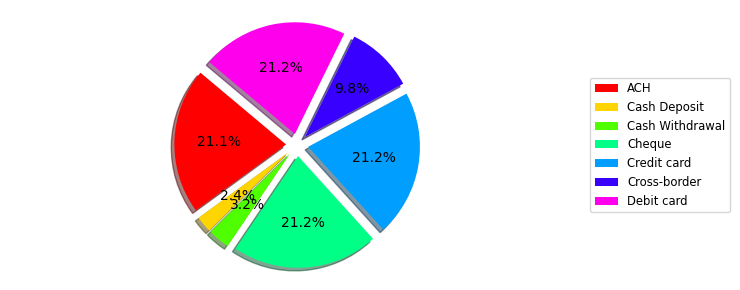

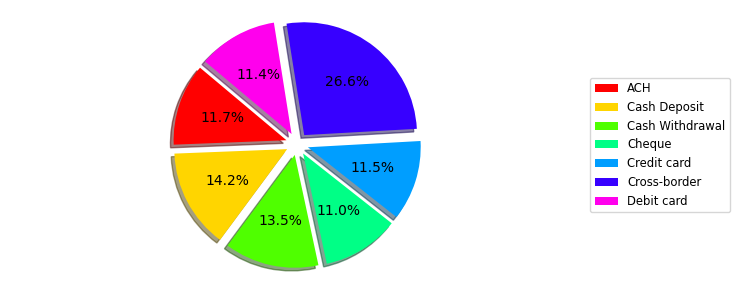

In [ ]:
n = 7
colors = [cmap(i/n) for i in range(n)]
pizza(colors=colors, coluna="Payment_type", dataframe=df)
pizza(colors=colors, coluna="Payment_type", dataframe=df[df['Is_laundering'] == 1])

In [ ]:
df[(df["Payment_type"] == "Cross-border") & (df["Sender_bank_location"] == df["Receiver_bank_location"])]

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type


In [ ]:
df[(df["Payment_type"] != "Cross-border") & (df["Sender_bank_location"] != df["Receiver_bank_location"]) & (df['Is_laundering'] == 1)]

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
1206,11:19:32,2022-10-07,6340007440,4316483340,106.04,UK pounds,Indian rupee,UK,India,Cash Withdrawal,1,Cash_Withdrawal
23487,06:51:19,2022-10-08,6340007440,4316483340,331.41,UK pounds,Indian rupee,UK,India,Cash Withdrawal,1,Cash_Withdrawal
43992,20:22:20,2022-10-08,5825377846,250142155,114.04,UK pounds,US dollar,UK,USA,Cash Withdrawal,1,Cash_Withdrawal
58518,11:23:49,2022-10-09,6088569153,5098225823,75.89,UK pounds,Indian rupee,UK,India,Cash Withdrawal,1,Cash_Withdrawal
75268,21:49:57,2022-10-09,5825377846,250142155,108.79,UK pounds,US dollar,UK,USA,Cash Withdrawal,1,Cash_Withdrawal
...,...,...,...,...,...,...,...,...,...,...,...,...
9440178,03:34:27,2023-08-21,7973448027,8391201653,207.46,UK pounds,Moroccan dirham,UK,Morocco,Cash Withdrawal,1,Cash_Withdrawal
9458292,17:46:47,2023-08-21,1600149721,2098207133,235.73,UK pounds,Naira,UK,Nigeria,Cash Withdrawal,1,Cash_Withdrawal
9464649,21:49:13,2023-08-21,6866095401,8817822667,325.81,UK pounds,Mexican Peso,UK,Mexico,Cash Withdrawal,1,Cash_Withdrawal
9492555,21:32:38,2023-08-22,7973448027,8391201653,338.25,UK pounds,Moroccan dirham,UK,Morocco,Cash Withdrawal,1,Cash_Withdrawal


In [ ]:
df[(df["Sender_bank_location"] == df["Receiver_bank_location"]) & (df['Is_laundering'] == 1)] #.groupby("Payment_type").count()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
317,10:46:37,2022-10-07,7401327478,4336451277,2603.300000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Smurfing
3304,12:39:03,2022-10-07,2758469152,2987279234,7832.410000,UK pounds,UK pounds,UK,UK,Debit card,1,Structuring
4664,13:30:06,2022-10-07,4624222122,8683543845,13837.820000,UK pounds,UK pounds,UK,UK,Credit card,1,Layered_Fan_Out
4754,13:33:59,2022-10-07,5262095561,927895922,4194.020000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Smurfing
5181,13:50:25,2022-10-07,2369776263,988008298,10511.870000,UK pounds,UK pounds,UK,UK,Debit card,1,Scatter-Gather
...,...,...,...,...,...,...,...,...,...,...,...,...
9490722,20:24:10,2023-08-22,9418604828,2824945595,3519.070000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Deposit-Send
9492002,21:12:14,2023-08-22,2926253452,3254039556,13190.320000,UK pounds,UK pounds,UK,UK,Credit card,1,Layered_Fan_In
9494741,22:55:12,2023-08-22,1636424035,4475683920,21064.140000,UK pounds,UK pounds,UK,UK,Cheque,1,Bipartite
9498521,05:10:16,2023-08-23,3177801471,3062645467,103.700000,UK pounds,UK pounds,UK,UK,Cash Withdrawal,1,Cash_Withdrawal


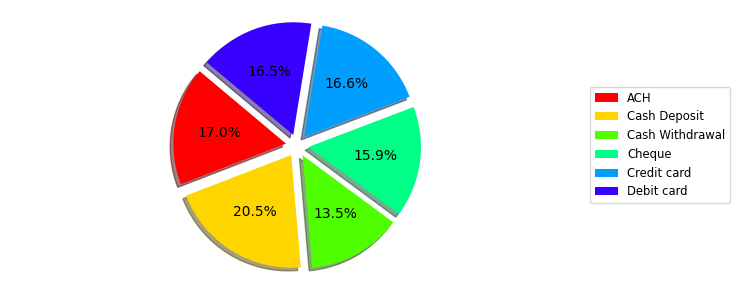

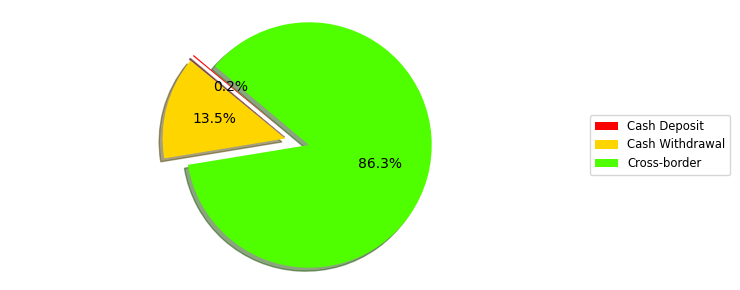

In [ ]:
n = 7
colors = [cmap(i/n) for i in range(n)]
pizza(colors=colors, coluna='Payment_type', dataframe=df[(df["Sender_bank_location"] == df["Receiver_bank_location"]) & (df['Is_laundering'] == 1)])
pizza(colors=colors, coluna='Payment_type', dataframe=df[(df["Sender_bank_location"] != df["Receiver_bank_location"]) & (df['Is_laundering'] == 1)])

In [ ]:
df[~((df["Payment_type"] != "Cross-border") & (df["Sender_bank_location"] != df["Receiver_bank_location"])) & (df["Is_laundering"] != 0)]

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
317,10:46:37,2022-10-07,7401327478,4336451277,2603.300000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Smurfing
1649,11:35:42,2022-10-07,3758118046,6081504025,5903.330000,UK pounds,Mexican Peso,UK,Mexico,Cross-border,1,Behavioural_Change_2
1954,11:45:53,2022-10-07,445154846,4497771501,3957.870000,UK pounds,Naira,UK,Nigeria,Cross-border,1,Structuring
3304,12:39:03,2022-10-07,2758469152,2987279234,7832.410000,UK pounds,UK pounds,UK,UK,Debit card,1,Structuring
3481,12:46:14,2022-10-07,5748489103,5971760311,3252.350000,UK pounds,US dollar,UK,USA,Cross-border,1,Behavioural_Change_1
...,...,...,...,...,...,...,...,...,...,...,...,...
9499725,07:56:34,2023-08-23,6347914836,8661825378,6702.170000,UK pounds,US dollar,UK,USA,Cross-border,1,Layered_Fan_In
9501820,09:12:18,2023-08-23,9285879778,7750754,814.490000,UK pounds,Euro,UK,Austria,Cross-border,1,Behavioural_Change_1
9501946,09:16:07,2023-08-23,351184098,4257557167,7888.580000,UK pounds,Turkish lira,UK,Turkey,Cross-border,1,Behavioural_Change_2
9503705,10:18:07,2023-08-23,7929569569,8236488006,30061.133364,UK pounds,UK pounds,UK,UK,Credit card,1,Cycle


In [ ]:
df[(df['Payment_currency'] == 'UK pounds') & (df['Received_currency'] == 'UK pounds') & (df['Sender_bank_location'] == 'UK') & (df['Receiver_bank_location'] == 'UK') & (df['Is_laundering'] == 1)]

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
317,10:46:37,2022-10-07,7401327478,4336451277,2603.300000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Smurfing
3304,12:39:03,2022-10-07,2758469152,2987279234,7832.410000,UK pounds,UK pounds,UK,UK,Debit card,1,Structuring
4664,13:30:06,2022-10-07,4624222122,8683543845,13837.820000,UK pounds,UK pounds,UK,UK,Credit card,1,Layered_Fan_Out
4754,13:33:59,2022-10-07,5262095561,927895922,4194.020000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Smurfing
5181,13:50:25,2022-10-07,2369776263,988008298,10511.870000,UK pounds,UK pounds,UK,UK,Debit card,1,Scatter-Gather
...,...,...,...,...,...,...,...,...,...,...,...,...
9490722,20:24:10,2023-08-22,9418604828,2824945595,3519.070000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Deposit-Send
9492002,21:12:14,2023-08-22,2926253452,3254039556,13190.320000,UK pounds,UK pounds,UK,UK,Credit card,1,Layered_Fan_In
9494741,22:55:12,2023-08-22,1636424035,4475683920,21064.140000,UK pounds,UK pounds,UK,UK,Cheque,1,Bipartite
9498521,05:10:16,2023-08-23,3177801471,3062645467,103.700000,UK pounds,UK pounds,UK,UK,Cash Withdrawal,1,Cash_Withdrawal


In [23]:
# Agrupando por conta e contando localizações únicas de bancos
locais_por_conta = df.groupby('Sender_account')['Sender_bank_location'].nunique()

# Calculando a média
media_locais = locais_por_conta.mean()

print(f'Média de Sender_bank_location diferentes por Sender_account: {media_locais:.4f}')

# Exibindo a distribuição para contexto
display(locais_por_conta.value_counts().sort_index().to_frame(name='Quantidade de Contas'))

Média de Sender_bank_location diferentes por Sender_account: 1.0184


,Quantidade de Contas
Sender_bank_location,
1,287867
2,4336
3,477
4,33
5,2


In [24]:
# Agrupando por conta e contando localizações únicas de bancos
locais_por_conta = df.groupby('Receiver_account')['Receiver_bank_location'].nunique()

# Calculando a média
media_locais = locais_por_conta.mean()

print(f'Média de Sender_bank_location diferentes por Sender_account: {media_locais:.4f}')

# Exibindo a distribuição para contexto
display(locais_por_conta.value_counts().sort_index().to_frame(name='Quantidade de Contas'))

Média de Sender_bank_location diferentes por Sender_account: 1.0062


,Quantidade de Contas
Receiver_bank_location,
1,648458
2,3577
3,222
4,9


In [ ]:
# Porcentagem de transações falsas por Sender
launderings_por_sender = df[df['Receiver_account'].isin( df[df['Is_laundering'] == 1]['Receiver_account'].unique() )].groupby('Receiver_account')['Is_laundering'].mean()

launderings_por_sender.quantile(0.45)

np.float64(0.1)

# Pensando em Features

Lista de features pensadas até então:
> 13 features, cada uma é um sender bank location. O valor da feature pode ser a quantidade de transações com esse bank location
>
> asda

## Sender e Receiver Bank Location

In [13]:
# Agrupando por conta e contando localizações únicas de bancos
locais_por_conta = df.groupby('Sender_account')['Sender_bank_location'].nunique()

# Calculando a média
media_locais = locais_por_conta.mean()

print(f'Média de Sender_bank_location diferentes por Sender_account: {media_locais:.4f}')

# Exibindo a distribuição para contexto
display(locais_por_conta.value_counts().sort_index().to_frame(name='Quantidade de Contas'))

Média de Sender_bank_location diferentes por Sender_account: 1.0184


,Quantidade de Contas
Sender_bank_location,
1,287867
2,4336
3,477
4,33
5,2


In [14]:
# Agrupando por conta e contando localizações únicas de bancos
locais_por_conta = df.groupby('Receiver_account')['Receiver_bank_location'].nunique()

# Calculando a média
media_locais = locais_por_conta.mean()

print(f'Média de Sender_bank_location diferentes por Sender_account: {media_locais:.4f}')

# Exibindo a distribuição para contexto
display(locais_por_conta.value_counts().sort_index().to_frame(name='Quantidade de Contas'))

Média de Sender_bank_location diferentes por Sender_account: 1.0062


,Quantidade de Contas
Receiver_bank_location,
1,648458
2,3577
3,222
4,9


In [16]:
np.random.exponential(size=(355888, 5))

array([[8.21606574e-02, 5.86026284e-01, 7.08061206e-03, 5.64105358e-01,
        2.65306717e+00],
       [4.95883737e-02, 3.46894691e-01, 1.75054960e+00, 1.12762149e+00,
        2.84515125e+00],
       [3.46535837e-01, 5.02257812e-01, 4.68817243e-01, 1.25717299e+00,
        1.28973441e+00],
       ...,
       [1.25401559e+00, 1.10955652e+00, 1.02884664e-03, 5.84255280e-03,
        1.53476586e+00],
       [4.10743199e-02, 5.58843604e+00, 5.64226450e-01, 4.58386149e-01,
        1.62461043e-01],
       [1.06158589e+00, 3.58750417e+00, 4.47443024e+00, 7.79285575e-01,
        8.43551019e-01]], shape=(355888, 5))